# Exploratory analysis of molten-salt corrosion data

This notebook describes the cleaned dataset and evaluates its modeling constraints. It does not fit or compare predictive models.

**Prediction objective:** Estimate corrosion rates for alloys that are absent from the training data.

The analysis uses chemical composition and test conditions. It treats `paper_id` and `alloy` as metadata to prevent identifier leakage.

## 1. Load data

Load the Parquet artifact from the cleaning notebook.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

for candidate in (Path.cwd(), *Path.cwd().parents):
    if (candidate / "pyproject.toml").is_file():
        PROJECT_ROOT = candidate
        break
else:
    raise FileNotFoundError("Could not find the project root with pyproject.toml")

DATA_PATH = PROJECT_ROOT / "data" / "processed" / "corrosion_data_clean.parquet"
if not DATA_PATH.is_file():
    raise FileNotFoundError(
        f"Clean data not found at {DATA_PATH}. Run notebooks/data_cleaning.ipynb first."
    )

data = pd.read_parquet(DATA_PATH)

TARGET = "corrosion_rate_um_per_year"
EXCLUDED_FROM_MODEL = ["paper_id", "alloy"]
HEADGAS_COLUMNS = [
    "headgas_air",
    "headgas_n2",
    "headgas_o2_sealed_loop",
]
COMPOSITION_COLUMNS = [column for column in data if column.endswith("_wt_pct")]
CONDITION_COLUMNS = [
    "temperature_c",
    "exposure_time_h",
    "flow_m_per_s",
    *HEADGAS_COLUMNS,
]
predictor_columns = [
    column
    for column in data.columns
    if column not in [TARGET, *EXCLUDED_FROM_MODEL]
]

required_columns = {
    TARGET,
    *EXCLUDED_FROM_MODEL,
    *HEADGAS_COLUMNS,
    *COMPOSITION_COLUMNS,
    *CONDITION_COLUMNS,
}
missing_columns = sorted(required_columns - set(data.columns))
if missing_columns:
    raise ValueError(f"The clean dataset is missing columns: {missing_columns}")
if data.empty:
    raise ValueError("The clean dataset has no rows")
if data[sorted(required_columns)].isna().any().any():
    raise ValueError("The clean dataset contains missing required values")

plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.max_columns", 30)
pd.set_option("display.float_format", lambda value: f"{value:,.3f}")

print(f"Loaded: {DATA_PATH}")
print(f"Shape: {data.shape[0]} rows x {data.shape[1]} columns")
print(f"Target: {TARGET}")
print(f"Model predictors: {len(predictor_columns)}")
print(f"Excluded identifiers: {EXCLUDED_FROM_MODEL}")

Loaded: /home/mhwkm/projects/molten_salt/data/processed/corrosion_data_clean.parquet
Shape: 109 rows x 25 columns
Target: corrosion_rate_um_per_year
Model predictors: 22
Excluded identifiers: ['paper_id', 'alloy']


## 2. Audit the dataset structure

Count studies, alloys, composition profiles, and repeated predictor rows. These counts define the effective sample size.

In [2]:
composition_profiles = data[COMPOSITION_COLUMNS].drop_duplicates()
predictor_duplicate_count = data.duplicated(subset=predictor_columns).sum()

schema_audit = pd.DataFrame(
    {
        "dtype": data.dtypes.astype(str),
        "missing": data.isna().sum(),
        "unique": data.nunique(dropna=False),
    }
)

dataset_findings = {
    "row_count": int(len(data)),
    "column_count": int(data.shape[1]),
    "paper_count": int(data["paper_id"].nunique()),
    "alloy_count": int(data["alloy"].nunique()),
    "unique_composition_count": int(len(composition_profiles)),
    "duplicate_predictor_rows": int(predictor_duplicate_count),
    "target_skew": float(data[TARGET].skew()),
    "maximum_temperature_c": float(data["temperature_c"].max()),
}

print("Dataset findings")
for finding, value in dataset_findings.items():
    print(f"- {finding}: {value}")

display(schema_audit)

Dataset findings
- row_count: 109
- column_count: 25
- paper_count: 6
- alloy_count: 26
- unique_composition_count: 29
- duplicate_predictor_rows: 3
- target_skew: 6.8478869739892305
- maximum_temperature_c: 4765.0


,dtype,missing,unique
paper_id,string,0,6
alloy,string,0,26
temperature_c,int64,0,28
exposure_time_h,float64,0,16
flow_m_per_s,float64,0,3
corrosion_rate_um_per_year,Float64,0,68
headgas_air,int8,0,2
headgas_n2,int8,0,2
headgas_o2_sealed_loop,int8,0,2
ni_wt_pct,float64,0,26


### Audit interpretation

Rows are not fully independent. Several rows can share a study, alloy, composition, or complete predictor profile.

The number of distinct compositions is more relevant than the row count for unseen-alloy prediction.

## 3. Check representation by study and alloy

Show sample imbalance and overlap between studies and alloys. Sparse groups can produce unstable validation scores.

,value
papers,6.000
alloys,26.000
alloys_with_one_row,14.000
alloys_found_in_one_paper_only,24.000
largest_paper_share,0.367
largest_alloy_share,0.147


paper_id,P002,P003,P004,P008,P010,P011
alloy,,,,,,
15-15Ti,1,0,0,0,0,0
304 stainless steel,0,0,0,0,0,7
304H,0,1,0,0,0,0
310N,1,0,0,0,0,0
316 stainless steel,0,0,0,0,0,7
316L,1,0,0,0,0,0
316Ti,1,0,0,0,0,0
321H,1,0,0,0,0,0
347,1,0,0,0,0,0


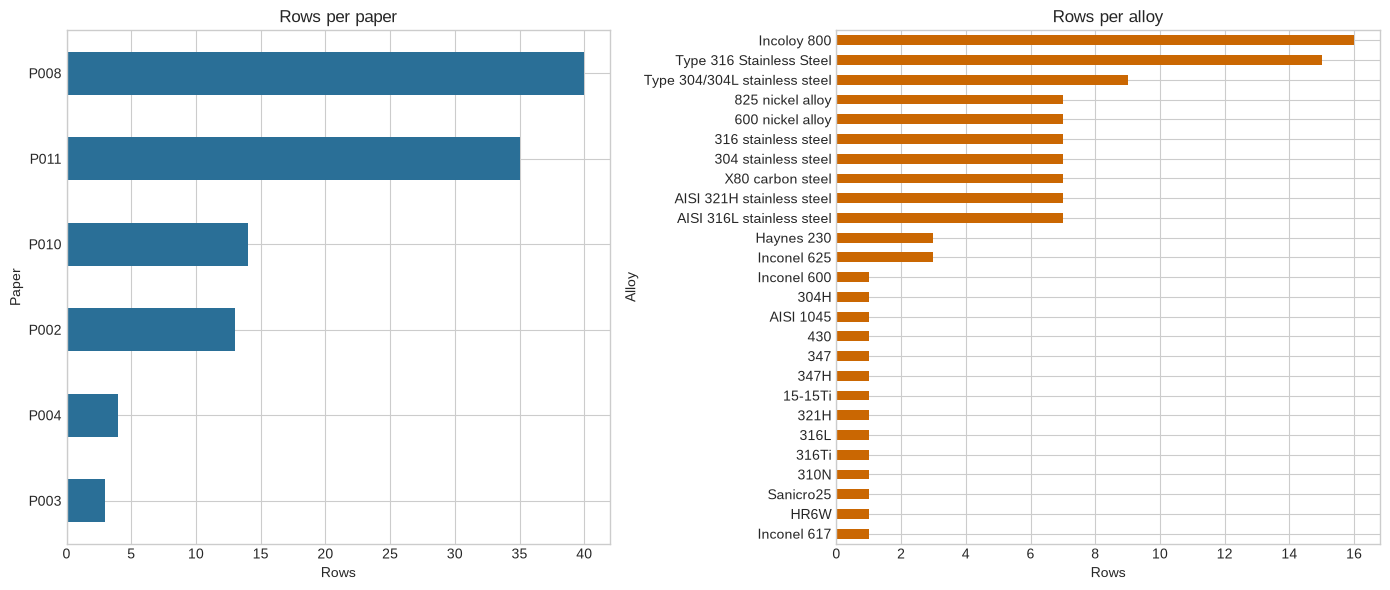

In [3]:
paper_counts = data["paper_id"].value_counts().rename("rows")
alloy_counts = data["alloy"].value_counts().rename("rows")
alloy_paper_table = pd.crosstab(data["alloy"], data["paper_id"])
alloys_in_one_paper = int((alloy_paper_table.gt(0).sum(axis=1) == 1).sum())

representation_summary = pd.Series(
    {
        "papers": len(paper_counts),
        "alloys": len(alloy_counts),
        "alloys_with_one_row": int((alloy_counts == 1).sum()),
        "alloys_found_in_one_paper_only": alloys_in_one_paper,
        "largest_paper_share": paper_counts.max() / len(data),
        "largest_alloy_share": alloy_counts.max() / len(data),
    },
    name="value",
)
display(representation_summary.to_frame())
display(alloy_paper_table)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
paper_counts.sort_values().plot.barh(ax=axes[0], color="#2a6f97")
axes[0].set(title="Rows per paper", xlabel="Rows", ylabel="Paper")
alloy_counts.sort_values().plot.barh(ax=axes[1], color="#ca6702")
axes[1].set(title="Rows per alloy", xlabel="Rows", ylabel="Alloy")
fig.tight_layout()
plt.show()

### Representation interpretation

A random row split can place related observations in training and test sets. This overlap can inflate the reported performance.

Use the alloy name only to define groups. Do not use it as a predictor for an unseen-alloy task.

## 4. Examine the target

Compare the raw and `log1p` scales. Check skew, extreme values, zeros, and the repeated value at 3 micrometers per year.

,value
mean,25.234
median,8.000
standard_deviation,86.856
skew,6.848
zero_count,1.000
count_equal_to_3,21.000
iqr_upper_fence,34.250
count_above_iqr_fence,11.000


,corrosion_rate_um_per_year
0.000,0.000
0.010,0.307
0.050,1.000
0.250,3.000
0.500,8.000
0.750,15.500
0.900,34.360
0.950,67.046
0.990,555.024
1.000,688.000


,paper_id,alloy,temperature_c,exposure_time_h,corrosion_rate_um_per_year
16,P004,Haynes 230,680,"1,025.000",688.000
18,P004,Inconel 625,680,"1,025.000",594.000
67,P010,AISI 321H stainless steel,550,120.000,106.800
81,P011,304 stainless steel,530,180.000,96.600
60,P010,AISI 316L stainless steel,550,120.000,75.600
13,P003,AISI 1045,500,"2,160.000",69.810
68,P010,AISI 321H stainless steel,550,240.000,62.900
84,P011,316 stainless steel,530,180.000,58.800
61,P010,AISI 316L stainless steel,550,240.000,53.300
87,P011,304 stainless steel,530,260.000,41.700


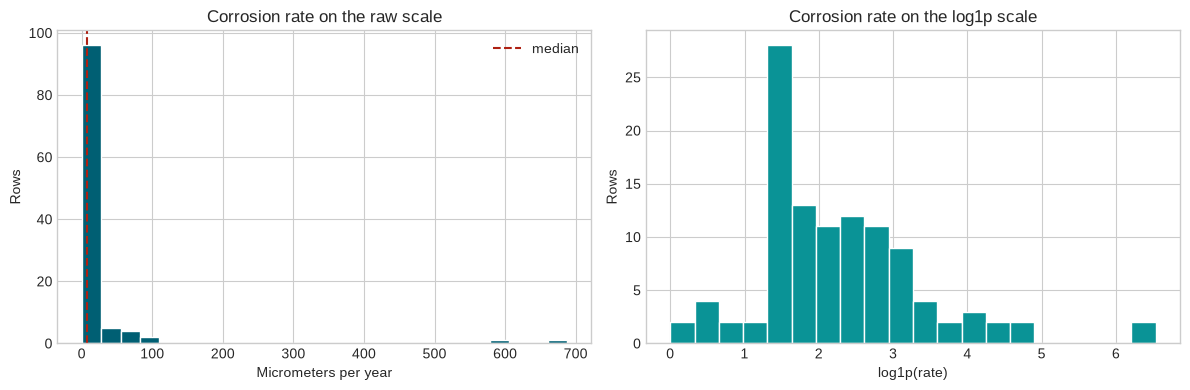

In [4]:
target_quantiles = data[TARGET].quantile(
    [0.00, 0.01, 0.05, 0.25, 0.50, 0.75, 0.90, 0.95, 0.99, 1.00]
).rename("corrosion_rate_um_per_year")
q1, q3 = data[TARGET].quantile([0.25, 0.75])
iqr = q3 - q1
upper_fence = q3 + 1.5 * iqr

point_mass_at_three = int(data[TARGET].eq(3).sum())
target_audit = pd.Series(
    {
        "mean": data[TARGET].mean(),
        "median": data[TARGET].median(),
        "standard_deviation": data[TARGET].std(),
        "skew": data[TARGET].skew(),
        "zero_count": data[TARGET].eq(0).sum(),
        "count_equal_to_3": point_mass_at_three,
        "iqr_upper_fence": upper_fence,
        "count_above_iqr_fence": data[TARGET].gt(upper_fence).sum(),
    },
    name="value",
)
display(target_audit.to_frame())
display(target_quantiles.to_frame())
display(
    data.nlargest(10, TARGET)[
        ["paper_id", "alloy", "temperature_c", "exposure_time_h", TARGET]
    ]
)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(data[TARGET], bins=25, color="#005f73", edgecolor="white")
axes[0].axvline(data[TARGET].median(), color="#ae2012", linestyle="--", label="median")
axes[0].set(title="Corrosion rate on the raw scale", xlabel="Micrometers per year", ylabel="Rows")
axes[0].legend()
axes[1].hist(np.log1p(data[TARGET]), bins=20, color="#0a9396", edgecolor="white")
axes[1].set(title="Corrosion rate on the log1p scale", xlabel="log1p(rate)", ylabel="Rows")
fig.tight_layout()
plt.show()

### Target interpretation

The strong right skew can make squared-error models focus on a few large values. Compare raw-target and `log1p`-target experiments later.

The cleaning step mapped values such as `<3` to `3`. The data cannot separate those censored values from exact measurements of 3.

Use robust metrics with RMSE. Suitable examples include MAE, median absolute error, and RMSLE when zero values remain valid.

## 5. Examine test conditions

Check ranges, cardinality, and extreme values. Do not correct a source value during EDA.

,minimum,median,maximum,unique,zero_fraction
temperature_c,350.000,530.000,"4,765.000",28,0.000
exposure_time_h,120.000,"2,000.000","4,500.000",16,0.000
flow_m_per_s,0.000,0.000,1.700,3,0.734
headgas_air,0.000,0.000,1.000,2,0.688
headgas_n2,0.000,0.000,1.000,2,0.679
headgas_o2_sealed_loop,0.000,0.000,1.000,2,0.633


Rows above 1000 C


,paper_id,alloy,temperature_c,exposure_time_h,corrosion_rate_um_per_year
42,P008,Type 316 Stainless Steel,4765,"4,500.000",3.000


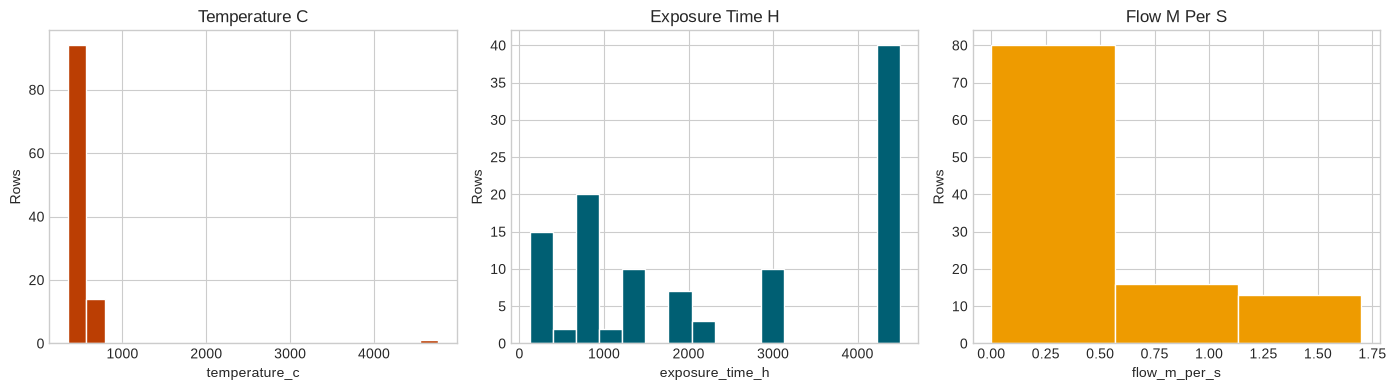

In [5]:
condition_summary = pd.DataFrame(
    {
        "minimum": data[CONDITION_COLUMNS].min(),
        "median": data[CONDITION_COLUMNS].median(),
        "maximum": data[CONDITION_COLUMNS].max(),
        "unique": data[CONDITION_COLUMNS].nunique(),
        "zero_fraction": data[CONDITION_COLUMNS].eq(0).mean(),
    }
)
display(condition_summary)

high_temperature_rows = data.loc[
    data["temperature_c"] > 1000,
    ["paper_id", "alloy", "temperature_c", "exposure_time_h", TARGET],
]
print("Rows above 1000 C")
display(high_temperature_rows)

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for axis, column, color in zip(
    axes,
    ["temperature_c", "exposure_time_h", "flow_m_per_s"],
    ["#bb3e03", "#005f73", "#ee9b00"],
):
    axis.hist(data[column], bins=min(20, data[column].nunique()), color=color, edgecolor="white")
    axis.set(title=column.replace("_", " ").title(), xlabel=column, ylabel="Rows")
fig.tight_layout()
plt.show()

## 6. Examine alloy compositions

Measure sparsity, cardinality, and dependence among element percentages. Composition features have a near-constant total by design.

,minimum,median,maximum,unique,zero_fraction
w_wt_pct,0.000,0.000,14.160,5,0.954
nb_wt_pct,0.000,0.000,4.150,6,0.936
co_wt_pct,0.000,0.000,15.000,8,0.917
n_wt_pct,0.000,0.000,0.350,9,0.807
al_wt_pct,0.000,0.000,1.500,8,0.771
cu_wt_pct,0.000,0.000,3.000,8,0.752
ti_wt_pct,0.000,0.000,0.700,10,0.716
p_wt_pct,0.000,0.000,0.045,8,0.541
s_wt_pct,0.000,0.000,0.050,9,0.523
mo_wt_pct,0.000,0.280,10.000,11,0.450


Composition total range: 97.140 to 100.300 wt.%


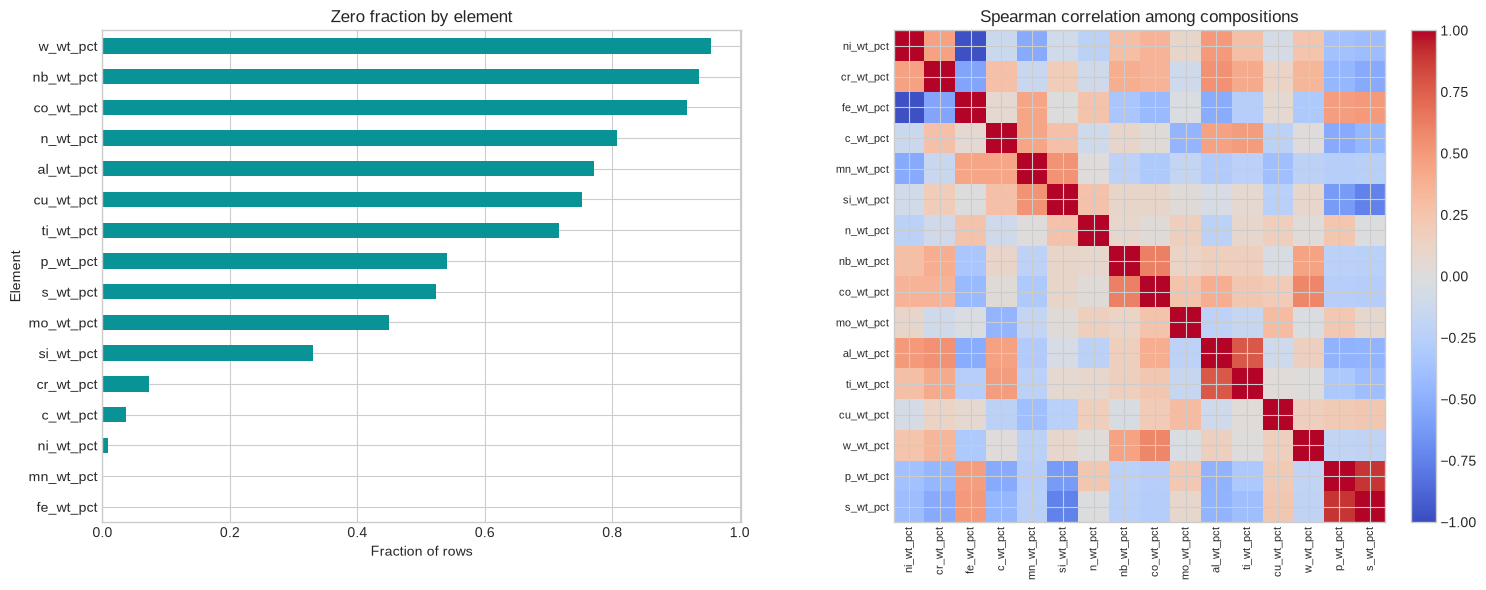

In [6]:
composition_summary = pd.DataFrame(
    {
        "minimum": data[COMPOSITION_COLUMNS].min(),
        "median": data[COMPOSITION_COLUMNS].median(),
        "maximum": data[COMPOSITION_COLUMNS].max(),
        "unique": data[COMPOSITION_COLUMNS].nunique(),
        "zero_fraction": data[COMPOSITION_COLUMNS].eq(0).mean(),
    }
).sort_values("zero_fraction", ascending=False)
composition_totals = data[COMPOSITION_COLUMNS].sum(axis=1)
composition_correlation = data[COMPOSITION_COLUMNS].corr(method="spearman")

display(composition_summary)
print(
    "Composition total range: "
    f"{composition_totals.min():.3f} to {composition_totals.max():.3f} wt.%"
)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
composition_summary["zero_fraction"].sort_values().plot.barh(
    ax=axes[0], color="#0a9396"
)
axes[0].set(title="Zero fraction by element", xlabel="Fraction of rows", ylabel="Element")
image = axes[1].imshow(composition_correlation, cmap="coolwarm", vmin=-1, vmax=1)
axes[1].set_xticks(range(len(COMPOSITION_COLUMNS)), COMPOSITION_COLUMNS, rotation=90, fontsize=8)
axes[1].set_yticks(range(len(COMPOSITION_COLUMNS)), COMPOSITION_COLUMNS, fontsize=8)
axes[1].set_title("Spearman correlation among compositions")
fig.colorbar(image, ax=axes[1], fraction=0.046, pad=0.04)
fig.tight_layout()
plt.show()

### Composition interpretation

Several elements are zero in most rows. The percentages also have strong dependence because their total stays near 100.

Linear regression can become unstable under this collinearity. Distance and kernel models require scaling and careful composition preprocessing.

Later experiments can compare raw percentages with log-ratio features. Zero values require a documented replacement before a log-ratio transform.

## 7. Examine predictor relationships with corrosion rate

Compare Pearson and Spearman correlations. Their differences can reveal nonlinear or outlier-driven associations.

,pearson,spearman,absolute_pearson,absolute_spearman
fe_wt_pct,-0.214,0.495,0.214,0.495
exposure_time_h,-0.205,-0.493,0.205,0.493
ni_wt_pct,0.175,-0.478,0.175,0.478
n_wt_pct,-0.023,0.437,0.023,0.437
p_wt_pct,0.024,0.435,0.024,0.435
headgas_o2_sealed_loop,-0.172,-0.389,0.172,0.389
headgas_air,0.265,0.374,0.265,0.374
temperature_c,0.033,0.324,0.033,0.324
s_wt_pct,0.038,0.296,0.038,0.296
al_wt_pct,0.044,-0.290,0.044,0.290


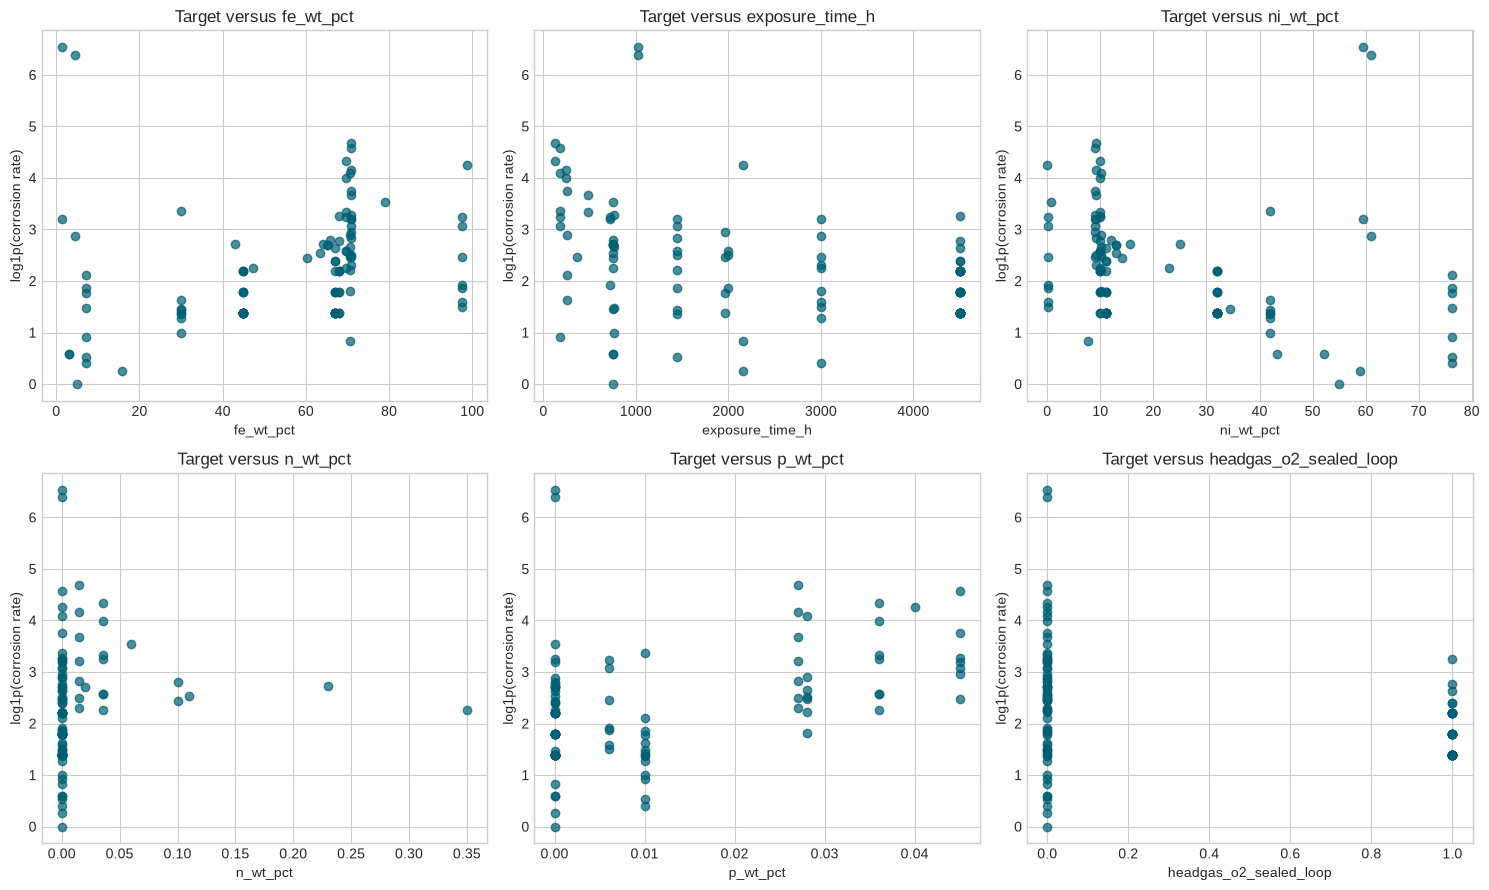

In [7]:
numeric_analysis_columns = [*predictor_columns, TARGET]
pearson_to_target = (
    data[numeric_analysis_columns].corr(method="pearson")[TARGET].drop(TARGET)
)
spearman_to_target = (
    data[numeric_analysis_columns].corr(method="spearman")[TARGET].drop(TARGET)
)
relationship_summary = pd.DataFrame(
    {
        "pearson": pearson_to_target,
        "spearman": spearman_to_target,
        "absolute_pearson": pearson_to_target.abs(),
        "absolute_spearman": spearman_to_target.abs(),
    }
).sort_values("absolute_spearman", ascending=False)
display(relationship_summary)

top_relationships = relationship_summary.head(6).index.tolist()
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
for axis, column in zip(axes.flat, top_relationships):
    axis.scatter(data[column], np.log1p(data[TARGET]), alpha=0.7, color="#005f73")
    axis.set(xlabel=column, ylabel="log1p(corrosion rate)", title=f"Target versus {column}")
fig.tight_layout()
plt.show()

### Relationship interpretation

No single correlation can establish a predictive mechanism. Different Pearson and Spearman values indicate possible curvature, thresholds, or influential rows.

Corrosion can depend on interactions between composition, temperature, exposure, flow, and atmosphere. This pattern favors controlled nonlinear models.

## 8. Assess coverage for unseen alloys

Estimate local composition coverage without fitting a predictive model. Standardize nonconstant composition columns before distance calculations.

,unique_compositions
alloy,
Inconel 625,2
Haynes 230,2
Type 304/304L stainless steel,2
304H,1
316 stainless steel,1
316L,1
316Ti,1
310N,1
15-15Ti,1


,value
alloy_composition_profiles,29.000
alloys_with_multiple_compositions,3.000
median_nearest_other_alloy_distance,2.084
maximum_nearest_other_alloy_distance,7.734
alloys_found_in_one_paper_only,24.000
duplicate_complete_predictor_rows,3.000


,alloy,nearest_other_alloy,standardized_distance
2,Inconel 617,Incoloy 800,7.734
13,AISI 1045,304 stainless steel,6.261
0,Inconel 625,Incoloy 800,6.004
17,Inconel 625,Inconel 600,4.786
4,Sanicro25,825 nickel alloy,3.799
28,825 nickel alloy,Sanicro25,3.799
24,X80 carbon steel,316 stainless steel,3.783
1,Haynes 230,HR6W,3.668
16,Haynes 230,HR6W,3.649
5,310N,321H,3.641


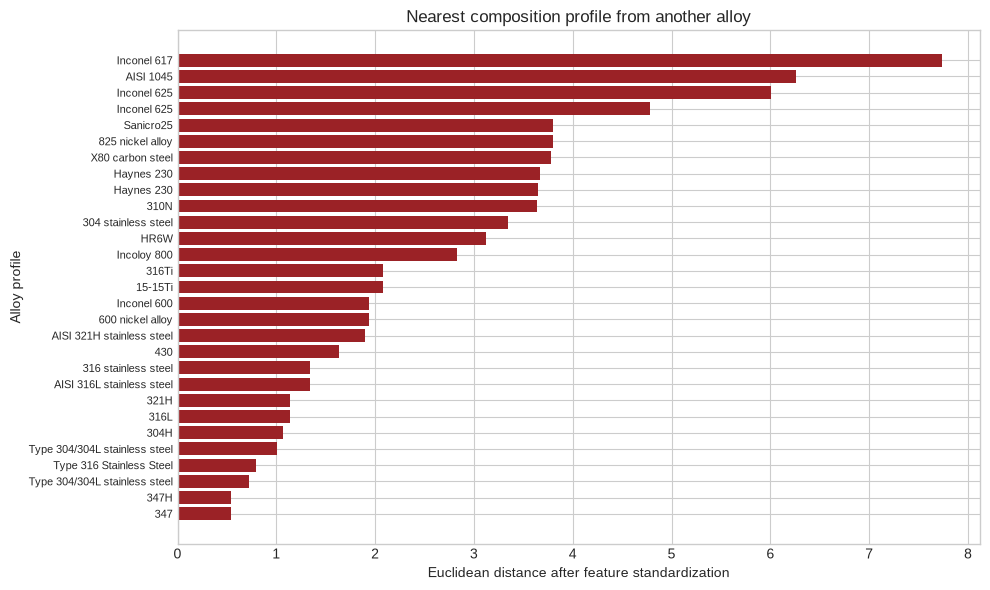

In [8]:
alloy_composition_counts = (
    data.groupby("alloy", observed=True)[COMPOSITION_COLUMNS]
    .apply(lambda group: len(group.drop_duplicates()), include_groups=False)
    .rename("unique_compositions")
    .sort_values(ascending=False)
)

profile_data = data[["alloy", *COMPOSITION_COLUMNS]].drop_duplicates().reset_index(drop=True)
profile_matrix = profile_data[COMPOSITION_COLUMNS].astype(float)
nonconstant_compositions = profile_matrix.columns[profile_matrix.std(ddof=0).gt(0)]
standardized_profiles = (
    profile_matrix[nonconstant_compositions] - profile_matrix[nonconstant_compositions].mean()
) / profile_matrix[nonconstant_compositions].std(ddof=0)

pairwise_distances = np.sqrt(
    ((standardized_profiles.to_numpy()[:, None, :] - standardized_profiles.to_numpy()[None, :, :]) ** 2).sum(axis=2)
)
same_alloy = (
    profile_data["alloy"].to_numpy()[:, None]
    == profile_data["alloy"].to_numpy()[None, :]
)
pairwise_distances[same_alloy] = np.inf
nearest_other_index = pairwise_distances.argmin(axis=1)
nearest_other_distance = pairwise_distances.min(axis=1)

coverage_table = pd.DataFrame(
    {
        "alloy": profile_data["alloy"],
        "nearest_other_alloy": profile_data.loc[nearest_other_index, "alloy"].to_numpy(),
        "standardized_distance": nearest_other_distance,
    }
).sort_values("standardized_distance", ascending=False)

coverage_findings = pd.Series(
    {
        "alloy_composition_profiles": len(profile_data),
        "alloys_with_multiple_compositions": int((alloy_composition_counts > 1).sum()),
        "median_nearest_other_alloy_distance": coverage_table["standardized_distance"].median(),
        "maximum_nearest_other_alloy_distance": coverage_table["standardized_distance"].max(),
        "alloys_found_in_one_paper_only": alloys_in_one_paper,
        "duplicate_complete_predictor_rows": predictor_duplicate_count,
    },
    name="value",
)
display(alloy_composition_counts.to_frame())
display(coverage_findings.to_frame())
display(coverage_table)

fig, axis = plt.subplots(figsize=(10, 6))
plot_coverage = coverage_table.sort_values("standardized_distance")
axis.barh(
    range(len(plot_coverage)),
    plot_coverage["standardized_distance"],
    color="#9b2226",
)
axis.set_yticks(range(len(plot_coverage)), plot_coverage["alloy"], fontsize=8)
axis.set(
    title="Nearest composition profile from another alloy",
    xlabel="Euclidean distance after feature standardization",
    ylabel="Alloy profile",
)
fig.tight_layout()
plt.show()

### Coverage interpretation

Large nearest-profile distances identify alloy compositions that require extrapolation. Predictions for these alloys need more caution than local interpolation.

## 9. Select three candidate model families

The table links observed data traits to model choices. These recommendations are hypotheses, not performance results.

Linear regression and random forest remain the agreed baselines. This notebook does not fit any model.

In [9]:
model_recommendations = pd.DataFrame(
    [
        {
            "model_key": "gradient_boosted_trees",
            "model_family": "Gradient-boosted trees",
            "evidence_from_data": (
                f"The target skew is {dataset_findings['target_skew']:.2f}. "
                "Corrosion can include thresholds and interactions among conditions and composition."
            ),
            "why_it_can_work": (
                "Boosting learns nonlinear effects and interactions on tabular data. "
                "Shallow trees and regularization can control variance."
            ),
            "main_risk": (
                "The effective sample size is small. Unconstrained boosting can overfit and cannot reliably extrapolate."
            ),
            "later_experiment": (
                "Tune shallow depth, learning rate, regularization, and raw versus log1p target within grouped validation."
            ),
            "fit_in_this_notebook": False,
        },
        {
            "model_key": "rbf_support_vector_regression",
            "model_family": "RBF support vector regression",
            "evidence_from_data": (
                f"Only {dataset_findings['unique_composition_count']} unique composition vectors exist across "
                f"{dataset_findings['row_count']} rows. Smooth nonlinear interpolation is plausible."
            ),
            "why_it_can_work": (
                "RBF SVR often performs well on small nonlinear datasets. The epsilon margin can reduce sensitivity to noise."
            ),
            "main_risk": (
                "Performance depends strongly on scaling, C, gamma, and epsilon. Predictions outside observed coverage are weak."
            ),
            "later_experiment": (
                "Scale continuous predictors inside each fold. Tune C, gamma, epsilon, and raw versus log1p target."
            ),
            "fit_in_this_notebook": False,
        },
        {
            "model_key": "gaussian_process_regression",
            "model_family": "Gaussian process regression",
            "evidence_from_data": (
                f"The dataset has {dataset_findings['row_count']} rows and uneven composition coverage. "
                "A small-data model can express uncertainty away from observed alloys."
            ),
            "why_it_can_work": (
                "A Matérn or rational-quadratic kernel can model smooth nonlinear response surfaces and predictive uncertainty."
            ),
            "main_risk": (
                "Sparse and dependent composition features can make kernel length scales unstable. Reduce or regularize dimensions."
            ),
            "later_experiment": (
                "Compare scaled raw features with a compact composition representation. Tune kernels only inside grouped folds."
            ),
            "fit_in_this_notebook": False,
        },
    ]
)

baseline_context = pd.DataFrame(
    [
        {
            "model": "Linear regression",
            "role": "Baseline",
            "expected_strength": "Simple and interpretable",
            "data_warning": "Collinearity, skew, interactions, and extreme values can violate assumptions.",
        },
        {
            "model": "Random forest",
            "role": "Baseline",
            "expected_strength": "Established nonlinear benchmark for this domain",
            "data_warning": "Small groups and unseen composition regions can produce unstable estimates.",
        },
    ]
)

validation_recommendation = "leave-one-alloy-out"

display(baseline_context)
display(model_recommendations)
print(f"Primary later validation design: {validation_recommendation}")
print("Secondary stress test: leave-one-paper-out")

,model,role,expected_strength,data_warning
0,Linear regression,Baseline,Simple and interpretable,"Collinearity, skew, interactions, and extreme ..."
1,Random forest,Baseline,Established nonlinear benchmark for this domain,Small groups and unseen composition regions ca...


,model_key,model_family,evidence_from_data,why_it_can_work,main_risk,later_experiment,fit_in_this_notebook
0,gradient_boosted_trees,Gradient-boosted trees,The target skew is 6.85. Corrosion can include...,Boosting learns nonlinear effects and interact...,The effective sample size is small. Unconstrai...,"Tune shallow depth, learning rate, regularizat...",False
1,rbf_support_vector_regression,RBF support vector regression,Only 29 unique composition vectors exist acros...,RBF SVR often performs well on small nonlinear...,"Performance depends strongly on scaling, C, ga...",Scale continuous predictors inside each fold. ...,False
2,gaussian_process_regression,Gaussian process regression,The dataset has 109 rows and uneven compositio...,A Matérn or rational-quadratic kernel can mode...,Sparse and dependent composition features can ...,Compare scaled raw features with a compact com...,False


Primary later validation design: leave-one-alloy-out
Secondary stress test: leave-one-paper-out


### Models not prioritized

- **Deep neural networks:** The dataset and the number of distinct compositions are too small for a reliable first experiment.
- **K-nearest neighbors:** Sparse high-dimensional compositions make distance sensitive to scaling and irrelevant dimensions.
- **High-degree polynomial regression:** Interaction expansion can exceed the effective sample size and amplify extreme values.
- **Alloy-name encoding:** A new alloy category has no learned coefficient or category effect.

These exclusions can change when more diverse data becomes available.

## 10. Modeling guidance

1. Keep `paper_id` and `alloy` out of the predictor matrix.
2. Use `alloy` to form leave-one-alloy-out validation folds.
3. Fit scaling, feature transforms, and hyperparameters inside each training fold.
4. Compare the raw target with a `log1p` target.
5. Report MAE with RMSE and a log-scale metric.
6. Report fold-level results because alloy groups have unequal sizes.
7. Repeat evaluation after source review of the `4765 °C` value.
8. Add a leave-one-paper-out stress test for study dependence.
9. Interpret predictions outside observed composition coverage with caution.